In [1]:
import numpy as np
import pandas as pd
from sklearn.datasets import make_classification

In [2]:
X,y = make_classification(n_features=5, n_redundant=0, n_informative=5,n_clusters_per_class=1)

In [3]:
df = pd.DataFrame(X,columns=['col1','col2','col3','col4','col5'])
df['target'] = y
print(df.shape)
df.head()

(100, 6)


,col1,col2,col3,col4,col5,target
0,1.258867,-2.682506,-0.042622,0.041046,-0.590324,1
1,-4.650272,-2.986678,2.380786,2.180520,-1.718387,0
2,0.380637,-2.397261,-0.350465,-0.616440,0.100796,0
3,-1.899306,-0.652537,1.290009,2.089539,0.380360,0
4,0.266800,0.413010,-0.834660,1.858806,1.154117,0


In [4]:
# function for row sampling

def sample_rows(df,percent):
  return df.sample(int(percent*df.shape[0]),replace=True)

In [8]:
import random

In [10]:
# function for feature sampling
def sample_features(df,percent):
  cols = random.sample(df.columns.tolist()[:-1],int(percent*(df.shape[1]-1)))
  new_df = df[cols]
  new_df['target'] = df['target']
  return new_df

In [11]:
# function for combined sampling

def combined_sampling(df,row_percent,col_percent):
  new_df = sample_rows(df,row_percent)
  return sample_features(new_df,col_percent)

In [12]:
df1 = combined_sampling(df,0.5,0.5)

/var/folders/zz/hz5n3gw12db770fjhgx44zj00000gn/T/ipykernel_11956/3275485051.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_df['target'] = df['target']


In [13]:
df2 = combined_sampling(df,0.5,0.5)

/var/folders/zz/hz5n3gw12db770fjhgx44zj00000gn/T/ipykernel_11956/3275485051.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_df['target'] = df['target']


In [14]:
df3 = combined_sampling(df,0.5,0.5)

/var/folders/zz/hz5n3gw12db770fjhgx44zj00000gn/T/ipykernel_11956/3275485051.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_df['target'] = df['target']


In [15]:
print(df1.columns)
print(df2.columns)
print(df3.columns)

Index(['col5', 'col1', 'target'], dtype='object')
Index(['col3', 'col1', 'target'], dtype='object')
Index(['col4', 'col1', 'target'], dtype='object')


In [16]:
df3

,col4,col1,target
34,-0.872645,1.003215,1
34,-0.872645,1.003215,1
5,-0.766234,0.680405,1
9,-0.065181,1.527313,0
49,1.790000,0.919438,1
87,-2.543675,1.039187,1
37,-1.835669,1.840304,1
46,-2.064287,-0.465279,1
95,-0.723871,1.752796,1
30,-1.918215,0.093751,1


In [17]:
from sklearn.tree import DecisionTreeClassifier
clf1 = DecisionTreeClassifier()
clf2 = DecisionTreeClassifier()
clf3 = DecisionTreeClassifier()

In [18]:
clf1.fit(df1.iloc[:,0:2],df1.iloc[:,-1])
clf2.fit(df2.iloc[:,0:2],df2.iloc[:,-1])
clf3.fit(df3.iloc[:,0:2],df3.iloc[:,-1])

DecisionTreeClassifier()

In [19]:
from sklearn.tree import plot_tree

[Text(0.625, 0.9, 'x[1] <= 0.47\ngini = 0.493\nsamples = 50\nvalue = [22.0, 28.0]'),
 Text(0.5, 0.7, 'x[1] <= 0.17\ngini = 0.153\nsamples = 24\nvalue = [22, 2]'),
 Text(0.5625, 0.8, 'True  '),
 Text(0.25, 0.5, 'x[1] <= -0.415\ngini = 0.087\nsamples = 22\nvalue = [21, 1]'),
 Text(0.125, 0.3, 'gini = 0.0\nsamples = 16\nvalue = [16, 0]'),
 Text(0.375, 0.3, 'x[1] <= -0.128\ngini = 0.278\nsamples = 6\nvalue = [5, 1]'),
 Text(0.25, 0.1, 'gini = 0.0\nsamples = 1\nvalue = [0, 1]'),
 Text(0.5, 0.1, 'gini = 0.0\nsamples = 5\nvalue = [5, 0]'),
 Text(0.75, 0.5, 'x[1] <= 0.414\ngini = 0.5\nsamples = 2\nvalue = [1, 1]'),
 Text(0.625, 0.3, 'gini = 0.0\nsamples = 1\nvalue = [0, 1]'),
 Text(0.875, 0.3, 'gini = 0.0\nsamples = 1\nvalue = [1, 0]'),
 Text(0.75, 0.7, 'gini = 0.0\nsamples = 26\nvalue = [0, 26]'),
 Text(0.6875, 0.8, '  False')]

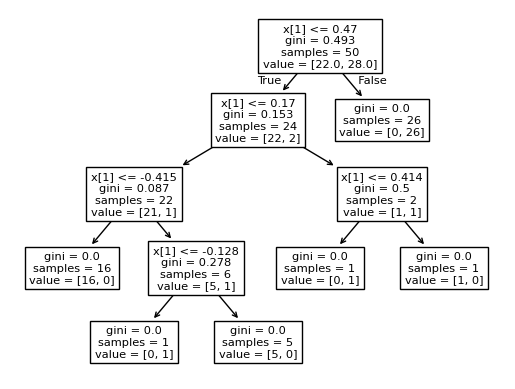

In [20]:
plot_tree(clf1)

[Text(0.4166666666666667, 0.9285714285714286, 'x[1] <= 0.102\ngini = 0.5\nsamples = 50\nvalue = [25, 25]'),
 Text(0.16666666666666666, 0.7857142857142857, 'x[1] <= -1.36\ngini = 0.153\nsamples = 24\nvalue = [22, 2]'),
 Text(0.2916666666666667, 0.8571428571428572, 'True  '),
 Text(0.08333333333333333, 0.6428571428571429, 'gini = 0.0\nsamples = 11\nvalue = [11, 0]'),
 Text(0.25, 0.6428571428571429, 'x[0] <= 2.034\ngini = 0.26\nsamples = 13\nvalue = [11, 2]'),
 Text(0.16666666666666666, 0.5, 'x[1] <= -1.186\ngini = 0.153\nsamples = 12\nvalue = [11, 1]'),
 Text(0.08333333333333333, 0.35714285714285715, 'gini = 0.0\nsamples = 1\nvalue = [0, 1]'),
 Text(0.25, 0.35714285714285715, 'gini = 0.0\nsamples = 11\nvalue = [11, 0]'),
 Text(0.3333333333333333, 0.5, 'gini = 0.0\nsamples = 1\nvalue = [0, 1]'),
 Text(0.6666666666666666, 0.7857142857142857, 'x[1] <= 2.046\ngini = 0.204\nsamples = 26\nvalue = [3, 23]'),
 Text(0.5416666666666666, 0.8571428571428572, '  False'),
 Text(0.5833333333333334, 0.6

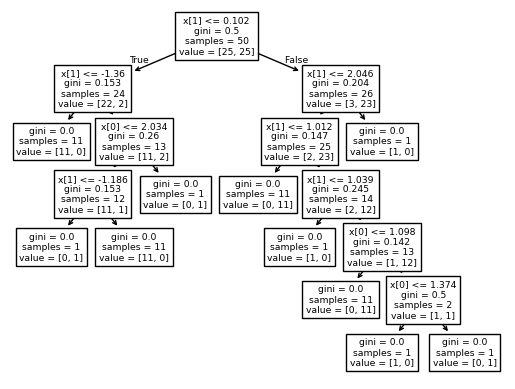

In [21]:
plot_tree(clf2)

[Text(0.2857142857142857, 0.9, 'x[0] <= -0.575\ngini = 0.493\nsamples = 50\nvalue = [22.0, 28.0]'),
 Text(0.14285714285714285, 0.7, 'gini = 0.0\nsamples = 23\nvalue = [0, 23]'),
 Text(0.21428571428571427, 0.8, 'True  '),
 Text(0.42857142857142855, 0.7, 'x[1] <= -0.307\ngini = 0.302\nsamples = 27\nvalue = [22, 5]'),
 Text(0.3571428571428571, 0.8, '  False'),
 Text(0.2857142857142857, 0.5, 'gini = 0.0\nsamples = 14\nvalue = [14, 0]'),
 Text(0.5714285714285714, 0.5, 'x[0] <= 0.62\ngini = 0.473\nsamples = 13\nvalue = [8, 5]'),
 Text(0.42857142857142855, 0.3, 'gini = 0.0\nsamples = 7\nvalue = [7, 0]'),
 Text(0.7142857142857143, 0.3, 'x[0] <= 2.075\ngini = 0.278\nsamples = 6\nvalue = [1, 5]'),
 Text(0.5714285714285714, 0.1, 'gini = 0.0\nsamples = 5\nvalue = [0, 5]'),
 Text(0.8571428571428571, 0.1, 'gini = 0.0\nsamples = 1\nvalue = [1, 0]')]

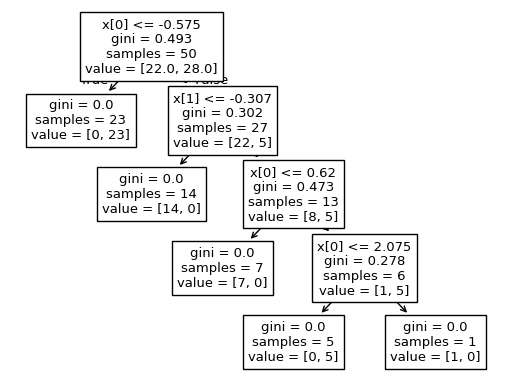

In [22]:
plot_tree(clf3)

In [23]:
clf1.predict(np.array([-1.042498,	-0.064323]).reshape(1,2))

/Users/apple/cxml/venv/lib/python3.9/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([0])

In [24]:
clf2.predict(np.array([-1.042498,	-0.064323]).reshape(1,2))

/Users/apple/cxml/venv/lib/python3.9/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([0])

In [25]:
clf3.predict(np.array([-1.042498,	-0.064323]).reshape(1,2))

/Users/apple/cxml/venv/lib/python3.9/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([1])

In [26]:
df.sample(14,replace=True)

,col1,col2,col3,col4,col5,target
43,0.938818,-1.144892,1.538537,-1.477520,-0.242973,1
79,1.276006,-3.013955,-0.576374,-0.569261,0.036704,1
76,-1.781377,-0.955049,-0.197503,1.627786,1.052502,0
42,1.058310,-2.731545,0.369420,-0.820109,-0.255661,1
93,0.051577,-0.547976,0.761507,1.424146,-0.139410,0
45,-1.578277,-0.377462,3.077529,2.659689,-1.016608,0
40,-0.908762,-0.922688,1.185047,-0.912040,0.924519,1
75,-2.202785,-1.501008,2.333709,1.077122,0.842425,0
65,0.316022,-1.444599,1.221284,-0.501652,-1.130338,1
43,0.938818,-1.144892,1.538537,-1.477520,-0.242973,1
